# 02 - Modelagem e Validacao

Notebook 2 do projeto. Treina e avalia Rede Neural, Arvore de Decisao e SVM usando os arrays gerados no notebook 01.

## 1) Setup e carga dos dados

In [1]:
import os
from pathlib import Path

os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

ROOT = Path("..").resolve()
DATA_PROCESSED = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"
FIGURES_DIR = ROOT / "reports" / "figures"
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

X_train = np.load(DATA_PROCESSED / "X_train.npy")
X_test = np.load(DATA_PROCESSED / "X_test.npy")
y_train = np.load(DATA_PROCESSED / "y_train.npy")
y_test = np.load(DATA_PROCESSED / "y_test.npy")
feature_names = (DATA_PROCESSED / "feature_names.txt").read_text(encoding="utf-8").splitlines()

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (4456, 15) X_test: (1114, 15)
y_train: (4456,) y_test: (1114,)


In [2]:
def calc_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

def calc_ein_eout(y_true_train, y_pred_train, y_true_test, y_pred_test):
    ein = 1 - accuracy_score(y_true_train, y_pred_train)
    eout = 1 - accuracy_score(y_true_test, y_pred_test)
    return ein, eout

## 2) Rede Neural

Arquitetura escolhida: `[p, 16, 8, 1]`. A dimensao VC aproximada e calculada por `sum((n_i + 1) * n_{i+1})`, incluindo bias.

arquitetura: [15, 16, 8, 1]
d_vc: 401
N_treino/d_vc: 11.11
regra de ouro (N >= 10*d_vc): True
epocas executadas: 41
melhor epoca: 29


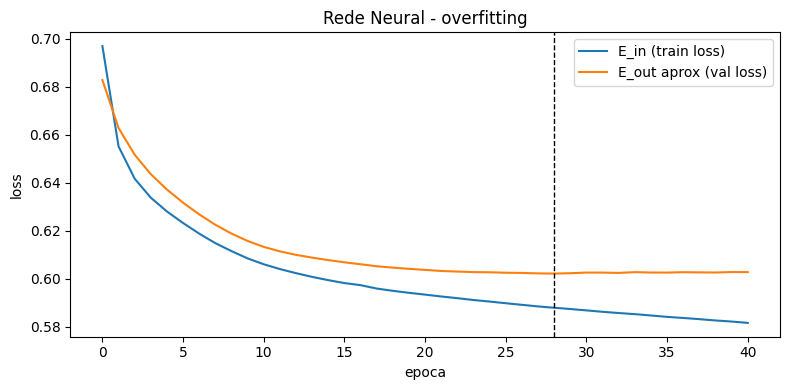

In [3]:
architecture = [X_train.shape[1], 16, 8, 1]
d_vc = sum((architecture[i] + 1) * architecture[i + 1] for i in range(len(architecture) - 1))
ratio = len(y_train) / d_vc

print("arquitetura:", architecture)
print("d_vc:", d_vc)
print("N_treino/d_vc:", round(ratio, 2))
print("regra de ouro (N >= 10*d_vc):", len(y_train) >= 10 * d_vc)

X_nn_train, X_nn_val, y_nn_train, y_nn_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train,
)

nn = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
nn.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy", metrics=["accuracy"])

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True)
history = nn.fit(
    X_nn_train,
    y_nn_train,
    validation_data=(X_nn_val, y_nn_val),
    epochs=120,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0,
)

best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print("epocas executadas:", len(history.history["loss"]))
print("melhor epoca:", best_epoch)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history["loss"], label="E_in (train loss)")
ax.plot(history.history["val_loss"], label="E_out aprox (val loss)")
ax.axvline(best_epoch - 1, color="black", linestyle="--", linewidth=1)
ax.set_title("Rede Neural - overfitting")
ax.set_xlabel("epoca")
ax.set_ylabel("loss")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "nn_overfitting.png", dpi=130)
plt.show()

In [4]:
nn_train_pred = (nn.predict(X_train, verbose=0).ravel() >= 0.5).astype(int)
nn_test_pred = (nn.predict(X_test, verbose=0).ravel() >= 0.5).astype(int)
nn_ein, nn_eout = calc_ein_eout(y_train, nn_train_pred, y_test, nn_test_pred)
nn_metrics = calc_metrics(y_test, nn_test_pred)

print("E_in:", round(nn_ein, 4), "E_out:", round(nn_eout, 4))
print(nn_metrics)

nn.save(MODELS_DIR / "neural_network.keras")

E_in: 0.3077 E_out: 0.3402
{'accuracy': 0.6597845601436265, 'precision': 0.663003663003663, 'recall': 0.6499102333931778, 'f1': 0.6563916591115141}


## 3) Arvore de Decisao

Primeiro treinamos sem poda (para observar overfitting). Depois regularizamos `ccp_alpha` com Minimal Cost-Complexity e cross validation.

sem poda -> E_in: 0.0 E_out: 0.3932


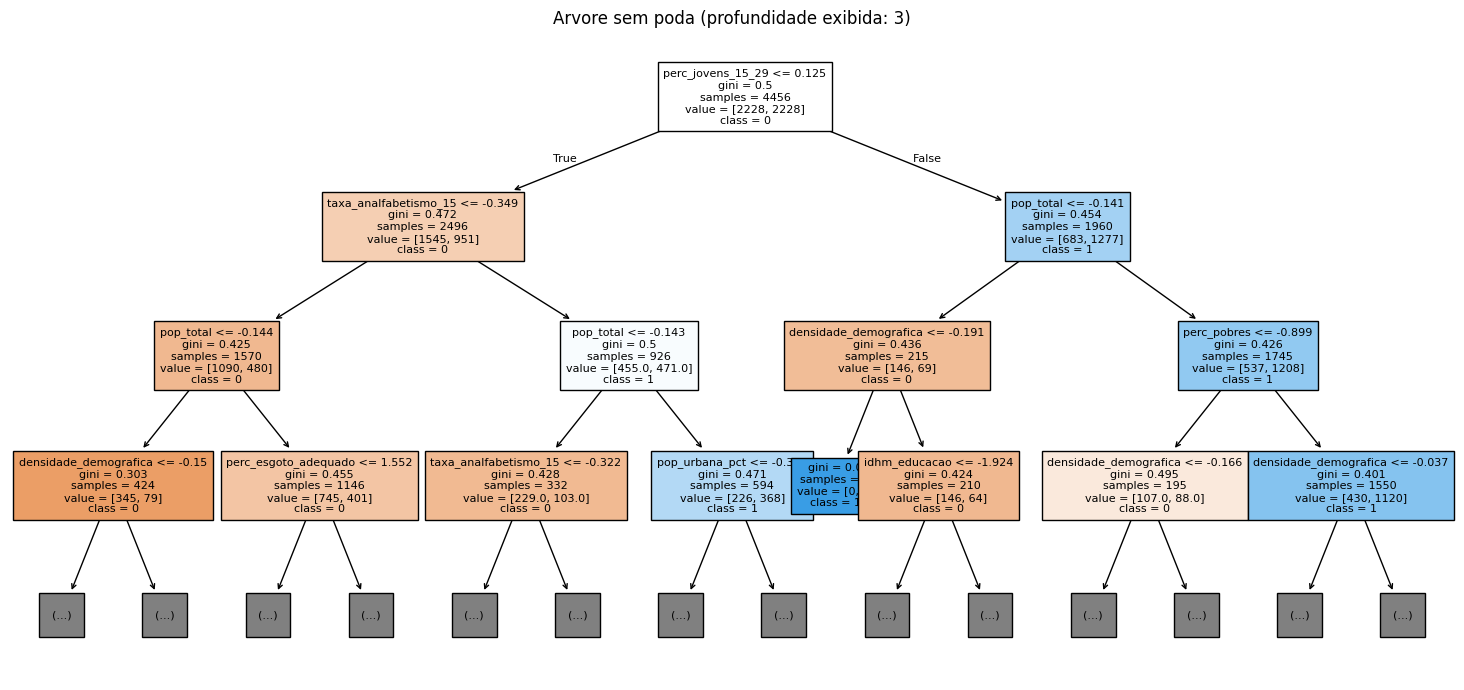

cv_folds: 10 best_alpha: 0.0025137369384127806


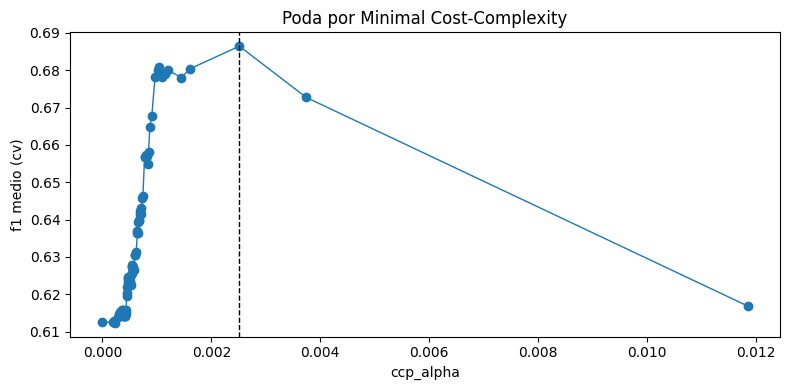

In [5]:
tree_raw = DecisionTreeClassifier(random_state=SEED)
tree_raw.fit(X_train, y_train)

tree_raw_train_pred = tree_raw.predict(X_train)
tree_raw_test_pred = tree_raw.predict(X_test)
tree_raw_ein, tree_raw_eout = calc_ein_eout(y_train, tree_raw_train_pred, y_test, tree_raw_test_pred)
print("sem poda -> E_in:", round(tree_raw_ein, 4), "E_out:", round(tree_raw_eout, 4))

fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(tree_raw, max_depth=3, filled=True, feature_names=feature_names, class_names=["0", "1"], fontsize=8, ax=ax)
ax.set_title("Arvore sem poda (profundidade exibida: 3)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "tree_unpruned_depth3.png", dpi=130)
plt.show()

cv_folds = 10 if len(y_train) >= 2000 else 5
path = tree_raw.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]
if len(alphas) > 120:
    idx = np.linspace(0, len(alphas) - 1, 120).astype(int)
    alphas = np.unique(alphas[idx])

cv_scores = []
for alpha in alphas:
    tree_tmp = DecisionTreeClassifier(random_state=SEED, ccp_alpha=float(alpha))
    score = cross_val_score(tree_tmp, X_train, y_train, cv=cv_folds, scoring="f1", n_jobs=-1).mean()
    cv_scores.append(score)

best_idx = int(np.argmax(cv_scores))
best_alpha = float(alphas[best_idx])
print("cv_folds:", cv_folds, "best_alpha:", best_alpha)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas, cv_scores, marker="o", linewidth=1)
ax.axvline(best_alpha, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("ccp_alpha")
ax.set_ylabel("f1 medio (cv)")
ax.set_title("Poda por Minimal Cost-Complexity")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "tree_alpha_cv.png", dpi=130)
plt.show()

podada -> E_in: 0.3009 E_out: 0.342
{'accuracy': 0.6579892280071813, 'precision': 0.6527777777777778, 'recall': 0.6750448833034112, 'f1': 0.6637246248896734}


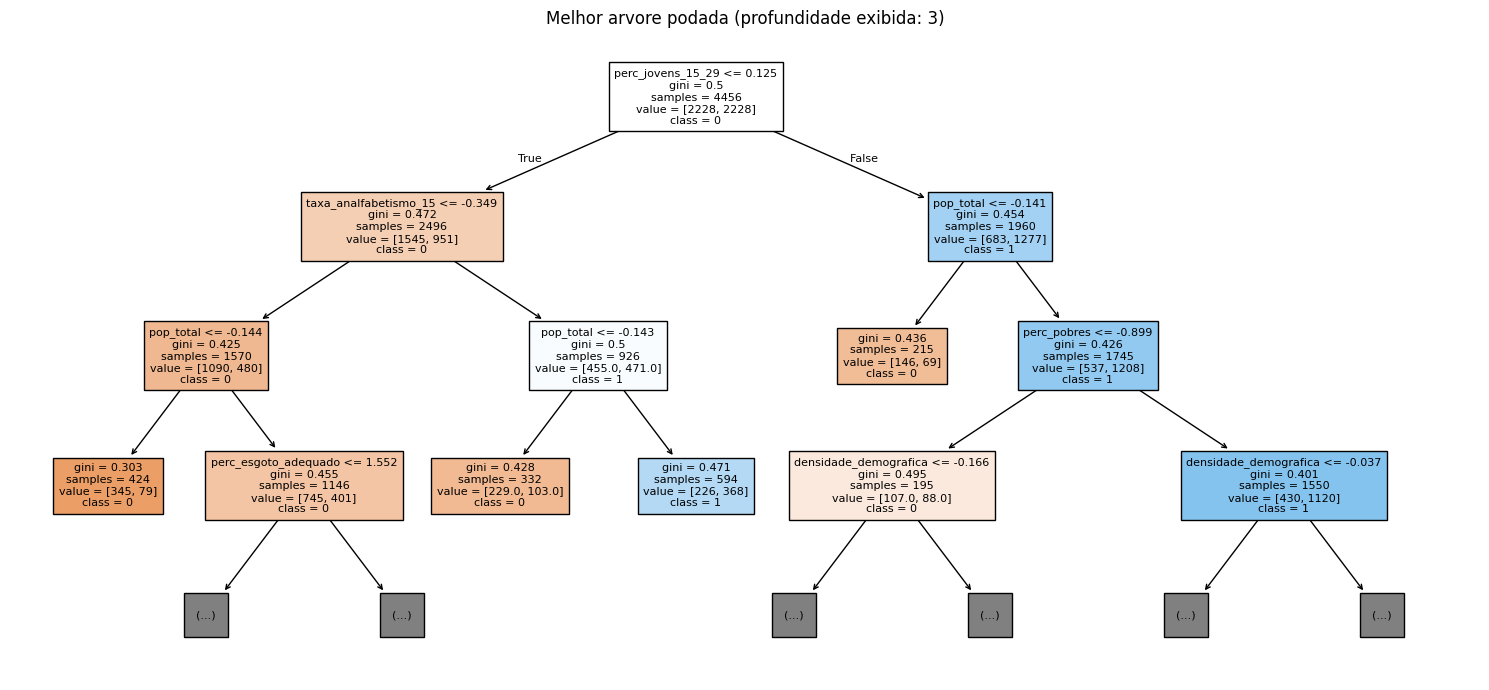

['/home/gabriel/projetos/socio_violence_predictor/models/decision_tree.joblib']

In [6]:
tree = DecisionTreeClassifier(random_state=SEED, ccp_alpha=best_alpha)
tree.fit(X_train, y_train)

tree_train_pred = tree.predict(X_train)
tree_test_pred = tree.predict(X_test)
tree_ein, tree_eout = calc_ein_eout(y_train, tree_train_pred, y_test, tree_test_pred)
tree_metrics = calc_metrics(y_test, tree_test_pred)

print("podada -> E_in:", round(tree_ein, 4), "E_out:", round(tree_eout, 4))
print(tree_metrics)

fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(tree, max_depth=3, filled=True, feature_names=feature_names, class_names=["0", "1"], fontsize=8, ax=ax)
ax.set_title("Melhor arvore podada (profundidade exibida: 3)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "tree_pruned_depth3.png", dpi=130)
plt.show()

joblib.dump(tree, MODELS_DIR / "decision_tree.joblib")

## 4) SVM

Regularizacao de `C` e `gamma` por `GridSearchCV`.

In [7]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, "scale"],
}

svm_grid = GridSearchCV(
    SVC(kernel="rbf"),
    param_grid=param_grid,
    cv=cv_folds,
    scoring="f1",
    n_jobs=-1,
    refit=True,
)
svm_grid.fit(X_train, y_train)
svm = svm_grid.best_estimator_
print("melhores parametros:", svm_grid.best_params_)

svm_train_pred = svm.predict(X_train)
svm_test_pred = svm.predict(X_test)
svm_ein, svm_eout = calc_ein_eout(y_train, svm_train_pred, y_test, svm_test_pred)
svm_metrics = calc_metrics(y_test, svm_test_pred)

n_support_vectors = int(svm.n_support_.sum())
svm_expected_eout = n_support_vectors / len(y_train)

print("E_in:", round(svm_ein, 4), "E_out:", round(svm_eout, 4), "E_out_esperado:", round(svm_expected_eout, 4))
print("n_support_vectors:", n_support_vectors)
print(svm_metrics)

joblib.dump(svm, MODELS_DIR / "svm.joblib")

melhores parametros: {'C': 100, 'gamma': 0.001}
E_in: 0.3131 E_out: 0.3339 E_out_esperado: 0.7255
n_support_vectors: 3233
{'accuracy': 0.6660682226211849, 'precision': 0.6513911620294599, 'recall': 0.7145421903052065, 'f1': 0.6815068493150684}


['/home/gabriel/projetos/socio_violence_predictor/models/svm.joblib']

## 5) Comparacao final e escolha do melhor modelo

Criterio de escolha: maior F1 no conjunto de teste apos validacao dos hiperparametros.

In [8]:
results = pd.DataFrame([
    {"modelo": "Rede Neural", **nn_metrics, "E_in": nn_ein, "E_out": nn_eout},
    {"modelo": "Arvore de Decisao", **tree_metrics, "E_in": tree_ein, "E_out": tree_eout},
    {"modelo": "SVM", **svm_metrics, "E_in": svm_ein, "E_out": svm_eout, "E_out_esperado": svm_expected_eout},
]).set_index("modelo")

results = results.sort_values("f1", ascending=False)
results.round(4)

,accuracy,precision,recall,f1,E_in,E_out,E_out_esperado
modelo,,,,,,,
SVM,0.6661,0.6514,0.7145,0.6815,0.3131,0.3339,0.7255
Arvore de Decisao,0.6580,0.6528,0.6750,0.6637,0.3009,0.3420,NaN
Rede Neural,0.6598,0.6630,0.6499,0.6564,0.3077,0.3402,NaN


In [9]:
best_model = results.index[0]
print("Melhor modelo pelo F1 no teste:", best_model)

results.to_csv(DATA_PROCESSED / "model_results.csv")
print("Resumo salvo em data/processed/model_results.csv")

Melhor modelo pelo F1 no teste: SVM
Resumo salvo em data/processed/model_results.csv
